# Synthetic game onboarding experiment

This notebook demonstrates the complete fixed-horizon workflow using deterministic **synthetic data**. It is an executable companion to `game_onboarding.py`; its outputs are not real-world evidence.

The estimand is always treatment minus control. Binary outcomes use the pooled score test and Newcombe hybrid Wilson interval. Session duration uses Welch inference. Holm adjustment controls family-wise error across the displayed metric family.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import JSON, Markdown, display

from examples.game_onboarding import build_report
from experimentation_toolkit import MetricType

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"control": "#4C78A8", "treatment": "#F58518", "interval": "#2F4B7C"}
report = build_report()

## 1. Assignment integrity

SRM is checked before metric interpretation. A failure suggests that observed assignment counts are inconsistent with the configured allocation. It does not identify the cause.

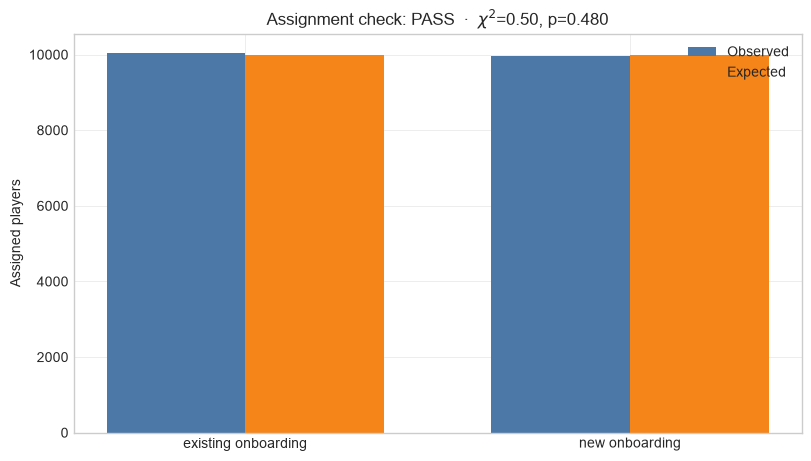

**Degrees of freedom:** 1
**Decision threshold:** 0.01
**Interpretation:** No sample ratio mismatch was detected at the selected threshold.

In [6]:
srm = report.diagnostics[0]
labels = list(srm.observed_counts)
observed = np.array([srm.observed_counts[label] for label in labels])
expected = np.array([srm.expected_counts[label] for label in labels])
x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.bar(x - width / 2, observed, width, label="Observed", color=COLORS["control"])
ax.bar(x + width / 2, expected, width, label="Expected", color=COLORS["treatment"])
ax.set_xticks(x, labels)
ax.set_ylabel("Assigned players")
title = (
    rf"Assignment check: {srm.status}  ·  $\chi^2$={srm.chi_square_statistic:.2f}, "
    f"p={srm.p_value:.3f}"
)
ax.set_title(title)
ax.legend(frameon=False)
plt.show()

display(
    Markdown(
        f"""**Degrees of freedom:** {srm.degrees_of_freedom}
**Decision threshold:** {srm.significance_level:g}
**Interpretation:** {srm.message}"""
    )
)

## 2. Effect estimates and uncertainty

Absolute effects remain on each metric's natural scale. The dashed line marks the point null. Confidence intervals quantify uncertainty; they do not determine practical importance.

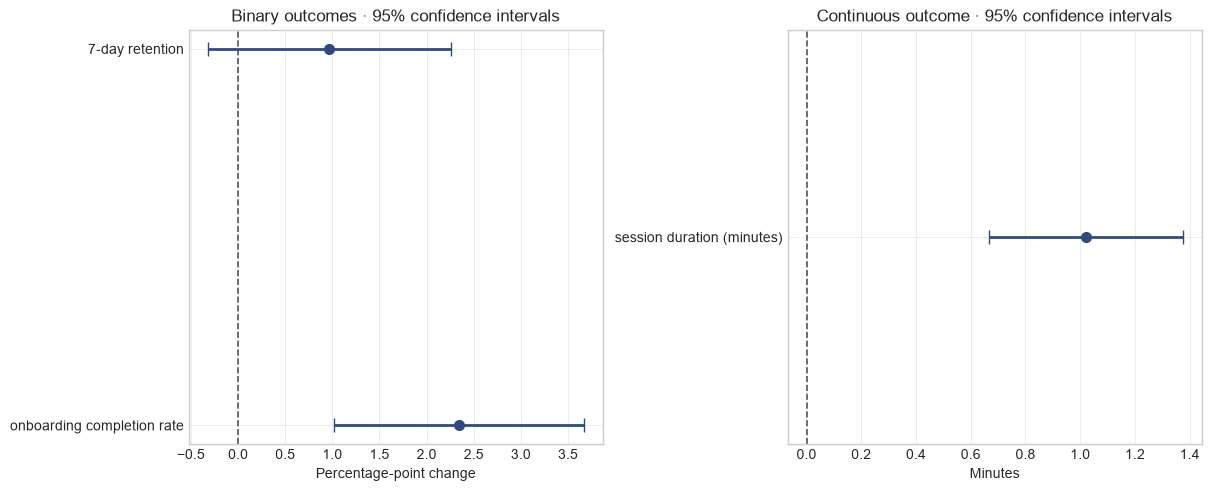

In [3]:
proportions = [item for item in report.analyses if item.metric_type is MetricType.PROPORTION]
continuous = [item for item in report.analyses if item.metric_type is MetricType.CONTINUOUS]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
for ax, analyses, multiplier, unit, title in [
    (axes[0], proportions, 100.0, "Percentage-point change", "Binary outcomes"),
    (axes[1], continuous, 1.0, "Minutes", "Continuous outcome"),
]:
    effects = np.array([item.absolute_effect * multiplier for item in analyses])
    lower = np.array([item.confidence_interval.lower * multiplier for item in analyses])
    upper = np.array([item.confidence_interval.upper * multiplier for item in analyses])
    positions = np.arange(len(analyses))
    errors = np.vstack((effects - lower, upper - effects))
    ax.errorbar(
        effects,
        positions,
        xerr=errors,
        fmt="o",
        color=COLORS["interval"],
        capsize=5,
        linewidth=2,
        markersize=7,
    )
    ax.axvline(0.0, color="#555555", linestyle="--", linewidth=1.2)
    ax.set_yticks(positions, [item.metric_name for item in analyses])
    ax.set_xlabel(unit)
    ax.set_title(f"{title} · 95% confidence intervals")
plt.show()

## 3. Multiplicity

The family contains the primary and secondary metrics shown here. Holm-adjusted p-values control the family-wise error rate. Adjustment does not turn statistical evidence into a business decision.

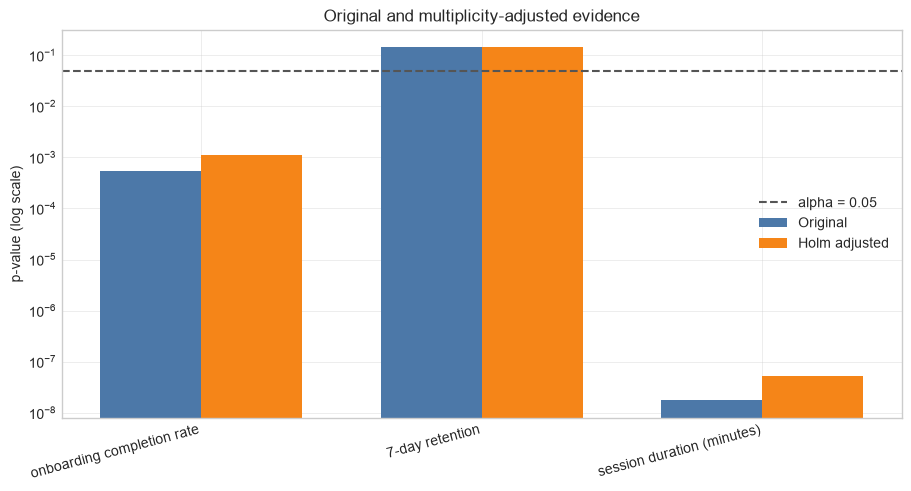

In [4]:
correction = report.multiple_testing
assert correction is not None
original = np.array(correction.original_p_values)
adjusted = np.array(correction.adjusted_p_values)
labels = list(correction.hypothesis_labels or ())
x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
ax.bar(x - width / 2, original, width, label="Original", color=COLORS["control"])
ax.bar(x + width / 2, adjusted, width, label="Holm adjusted", color=COLORS["treatment"])
ax.axhline(correction.alpha, color="#555555", linestyle="--", label=f"alpha = {correction.alpha:g}")
ax.set_yscale("log")
ax.set_xticks(x, labels, rotation=15, ha="right")
ax.set_ylabel("p-value (log scale)")
ax.set_title("Original and multiplicity-adjusted evidence")
ax.legend(frameon=False)
plt.show()

## 4. Structured report

All public results are immutable Pydantic models. Unbounded interval endpoints use `None` and serialize as JSON `null`; NaN and infinity are rejected.

In [7]:
payload = json.loads(report.model_dump_json())
display(
    JSON(
        {
            "experiment": payload["experiment"],
            "srm": payload["diagnostics"][0],
            "multiple_testing": payload["multiple_testing"],
        },
        expanded=False,
    )
)

json_length = len(report.model_dump_json())
print(
    f"Serialized report contains {len(payload['analyses'])} analyses "
    f"and {json_length} JSON characters."
)

<IPython.core.display.JSON object>

Serialized report contains 3 analyses and 4112 JSON characters.


## Interpretation boundary

The report supports three statements: the observed effect estimate, its uncertainty, and the evidence against the configured null. Statistical significance alone does not establish that an effect is beneficial, practically important, or worth deploying.